# 🪜 Step 1: Basic LSTM Baseline (Memory-Safe Direct Load)

This version loads data sequentially to prevent Colab RAM crashes while still providing `X_train`, `X_val`, and `X_test` variables.

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import gc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Reshape
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm
from google.colab import drive

# if os.path.exists('/content/drive'):
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Configuration

In [5]:
DATA_PATH = '/content/drive/MyDrive/Final Year Project/Data/Processed'
REFERENCE_PATH = os.path.join(DATA_PATH, 'reference.csv')

SEQUENCE_LENGTH = 30
NUM_LANDMARKS = 92
NUM_COORDS = 3

ref_data = pd.read_csv(REFERENCE_PATH)
ACTIONS = ref_data['gloss'].unique()
NUM_CLASSES = len(ACTIONS)
label_map = {label:num for num, label in enumerate(ACTIONS)}
inv_label_map = {num:label for label, num in label_map.items()}

print(f"Total Classes: {NUM_CLASSES}")

Total Classes: 2000


## 2. Memory-Safe Data Loading
We load files one-by-one in a simple loop to keep RAM usage low and flat.

In [ ]:
def load_data_subset_safe(subset):
    path = os.path.join(DATA_PATH, subset)
    X, y = [], []
    files = [f for f in os.listdir(path) if f.endswith('.npy')]
    
    print(f"Loading {len(files)} files for {subset}...")
    for f in tqdm(files):
        # Load data
        data = np.load(os.path.join(path, f))
        
        # Get label
        video_id = f.split('.')[0].split(' ')[0]
        if video_id.isnumeric():
            video_id = int(video_id)
        
        gloss_match = ref_data[ref_data['video_id'] == video_id]
        if not gloss_match.empty:
            X.append(data)
            y.append(label_map[gloss_match['gloss'].values[0]])
            
    # Convert to arrays and clear list memory
    X_arr = np.array(X, dtype=np.float32)
    y_arr = tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)
    
    del X, y
    gc.collect()
    return X_arr, y_arr

X_train, y_train = load_data_subset_safe('train')
X_val, y_val = load_data_subset_safe('val')
X_test, y_test = load_data_subset_safe('test')

Loading 8724 files for train...


  0%|          | 0/8724 [00:00<?, ?it/s]

## 3. Training LSTM Baseline

In [ ]:
model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, NUM_LANDMARKS, NUM_COORDS)),
    Reshape((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS)),
    LSTM(128, return_sequences=True, activation='tanh'),
    Dropout(0.2),
    LSTM(256, return_sequences=False, activation='tanh'),
    Dense(256, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32)

Epoch 1/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.0014 - loss: 7.5148 - val_accuracy: 0.0013 - val_loss: 7.2839
Epoch 2/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0024 - loss: 7.1190 - val_accuracy: 4.2589e-04 - val_loss: 7.2480
Epoch 3/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0031 - loss: 7.0012 - val_accuracy: 0.0021 - val_loss: 7.2417
Epoch 4/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0030 - loss: 6.9364 - val_accuracy: 0.0000e+00 - val_loss: 7.2522
Epoch 5/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0033 - loss: 6.8860 - val_accuracy: 0.0013 - val_loss: 7.3321
Epoch 6/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0039 - loss: 6.8338 - val_accuracy: 0.0013 - val_loss: 7.3382
Epoch 7/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0036 - loss: 6.7985 - val_accuracy: 0.0026 - val_loss: 7.3743
Epoch 8/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0044 - loss: 6

## 4. Performance Analysis

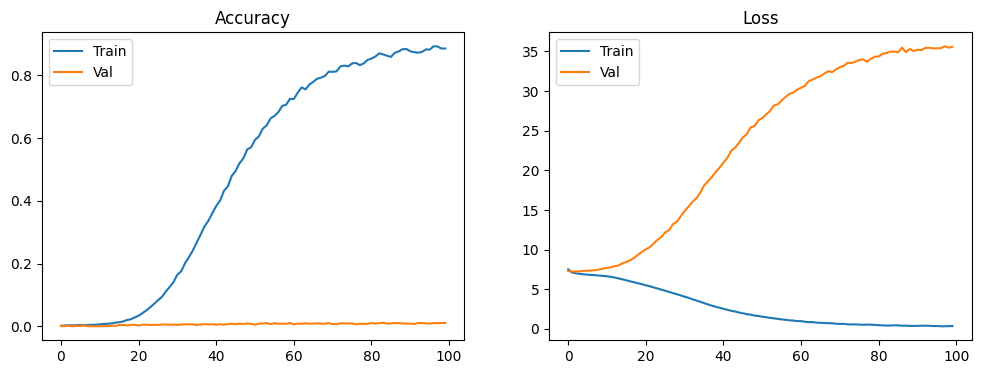

In [ ]:
def plot_performance(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_performance(history)

## Addition: Simple RNN experiment (non-destructive)

This cell adds a lightweight SimpleRNN baseline so you can compare behaviour with the LSTM model without modifying existing cells. It uses EarlyStopping + ModelCheckpoint and prints evaluation metrics.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 30, 276)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 30, 128)        │        51,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2000)           │       258,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 359,248 (1.37 MB)

 Trainable params: 359,248 (1.37 MB)

 Non-trainable params: 0 (0.00 B)

...

273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0025 - loss: 7.2441 - val_accuracy: 0.0013 - val_loss: 7.4275
Epoch 13/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.0028 - loss: 7.2199 - val_accuracy: 4.2589e-04 - val_loss: 7.4283
Epoch 14/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0022 - loss: 7.2143 - val_accuracy: 4.2589e-04 - val_loss: 7.4410
Epoch 15/50
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0021 - loss: 7.1887

273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0024 - loss: 7.1923 - val_accuracy: 4.2589e-04 - val_loss: 7.4050
Epoch 16/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0028 - loss: 7.1596

273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0025 - loss: 7.1718 - val_accuracy: 0.0017 - val_loss: 7.3704
Epoch 17/50
271/273 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0026 - loss: 7.1469

273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0022 - loss: 7.1629 - val_accuracy: 0.0021 - val_loss: 7.3678
Epoch 18/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0022 - loss: 7.1473 - val_accuracy: 0.0021 - val_loss: 7.4006
Epoch 19/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0032 - loss: 7.1294 - val_accuracy: 0.0013 - val_loss: 7.3995
Epoch 20/50
270/273 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0028 - loss: 7.1200

273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0032 - loss: 7.1290 - val_accuracy: 0.0017 - val_loss: 7.3671
Epoch 21/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0028 - loss: 7.1166 - val_accuracy: 0.0017 - val_loss: 7.3853
Epoch 22/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0026 - loss: 7.1112 - val_accuracy: 0.0017 - val_loss: 7.3781
Epoch 23/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0030 - loss: 7.1331 - val_accuracy: 0.0017 - val_loss: 7.5317
Epoch 24/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0032 - loss: 7.1641 - val_accuracy: 0.0017 - val_loss: 7.4226
Epoch 25/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0018 - loss: 7.2124 - val_accuracy: 8.5179e-04 - val_loss: 7.7271
Epoch 26/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0024 - loss: 7.3035 - val_accuracy: 8.5179e-04 - val_loss: 7.7070
Epoch 27/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0030 - loss: 7.2953 - val_accur

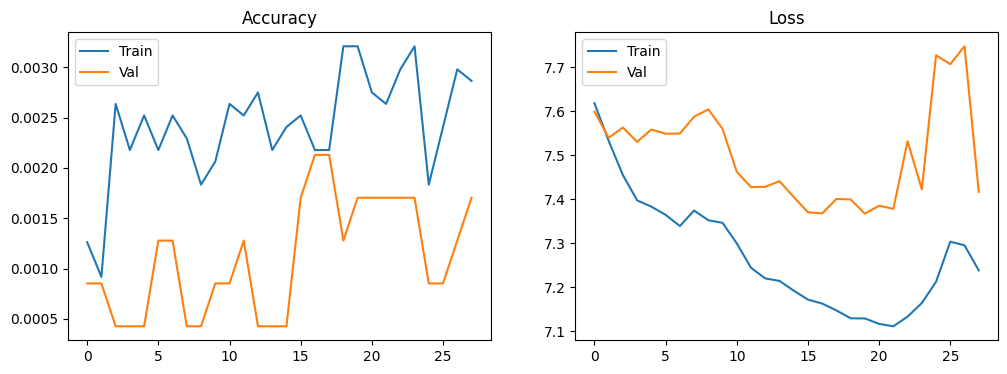

In [ ]:
# Simple RNN baseline (keeps original cells unchanged)
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Build a modest SimpleRNN model -- smaller capacity to reduce overfitting
rnn_model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, NUM_LANDMARKS, NUM_COORDS)),
    Reshape((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS)),
    SimpleRNN(128, return_sequences=True, activation='tanh'),
    Dropout(0.4),
    SimpleRNN(128, return_sequences=False, activation='tanh'),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

# Callbacks: early stop and save best model for inspection
early_rnn = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
chkpt_rnn = ModelCheckpoint('rnn_best.h5', monitor='val_loss', save_best_only=True)

# Train for fewer epochs first to get a quick comparison
history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_rnn, chkpt_rnn]
)

# Evaluate on test set
loss_rnn, acc_rnn = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f'RNN Test Loss: {loss_rnn:.4f} | RNN Test Acc: {acc_rnn:.4f}')

# Plot training curves if helper exists
try:
    plot_performance(history_rnn)
except Exception as e:
    print('plot_performance not found or failed:', e)

## Addition: Extra model variants for comparison

These models do not replace the existing LSTM or SimpleRNN baselines. They add two more options: a more regularized LSTM and a compact transformer-style sequence model.

In [ ]:
from tensorflow.keras.layers import Bidirectional, Conv1D, GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention, Add, SpatialDropout1D

def build_regularized_lstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(64, return_sequences=True, activation='tanh')),
        SpatialDropout1D(0.3),
        LSTM(64, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        LSTM(32, return_sequences=False, activation='tanh'),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    attn_output = Dropout(dropout)(attn_output)
    x = Add()([x, attn_output])
    x = LayerNormalization(epsilon=1e-6)(x)

    ff_output = Conv1D(ff_dim, kernel_size=1, activation='relu')(x)
    ff_output = Dropout(dropout)(ff_output)
    ff_output = Conv1D(x.shape[-1], kernel_size=1)(ff_output)
    x = Add()([x, ff_output])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_compact_transformer(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = SpatialDropout1D(0.2)(x)
    x = transformer_encoder_block(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.2)
    x = transformer_encoder_block(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.2)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs, name='compact_transformer')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Optional helper if you want to train a variant manually later
def compile_variant_report(model, name, x_train, y_train, x_val, y_val, epochs=25):
    print(f'\n=== {name} ===')
    model.summary()
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs, batch_size=32)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'{name} Test Loss: {loss:.4f} | {name} Test Acc: {acc:.4f}')
    return history


In [ ]:
# Build the additional variants without replacing the existing working models
regularized_lstm_model = build_regularized_lstm((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS), NUM_CLASSES)
compact_transformer_model = build_compact_transformer((SEQUENCE_LENGTH, NUM_LANDMARKS * NUM_COORDS), NUM_CLASSES)

print('Regularized LSTM summary:')
regularized_lstm_model.summary()

print('Compact Transformer summary:')
compact_transformer_model.summary()

# Keep these objects available for side-by-side experiments
model_variants = {
    'baseline_lstm': model,
    'simple_rnn': rnn_model,
    'regularized_lstm': regularized_lstm_model,
    'compact_transformer': compact_transformer_model,
}